In [ ]:
library(MASS)


# Set options

In [1]:
options(repr.plot.width = 15, repr.plot.height = 8)
set.seed(seed = 1)


# Simulating one gene

## Unimodal data

### Poisson

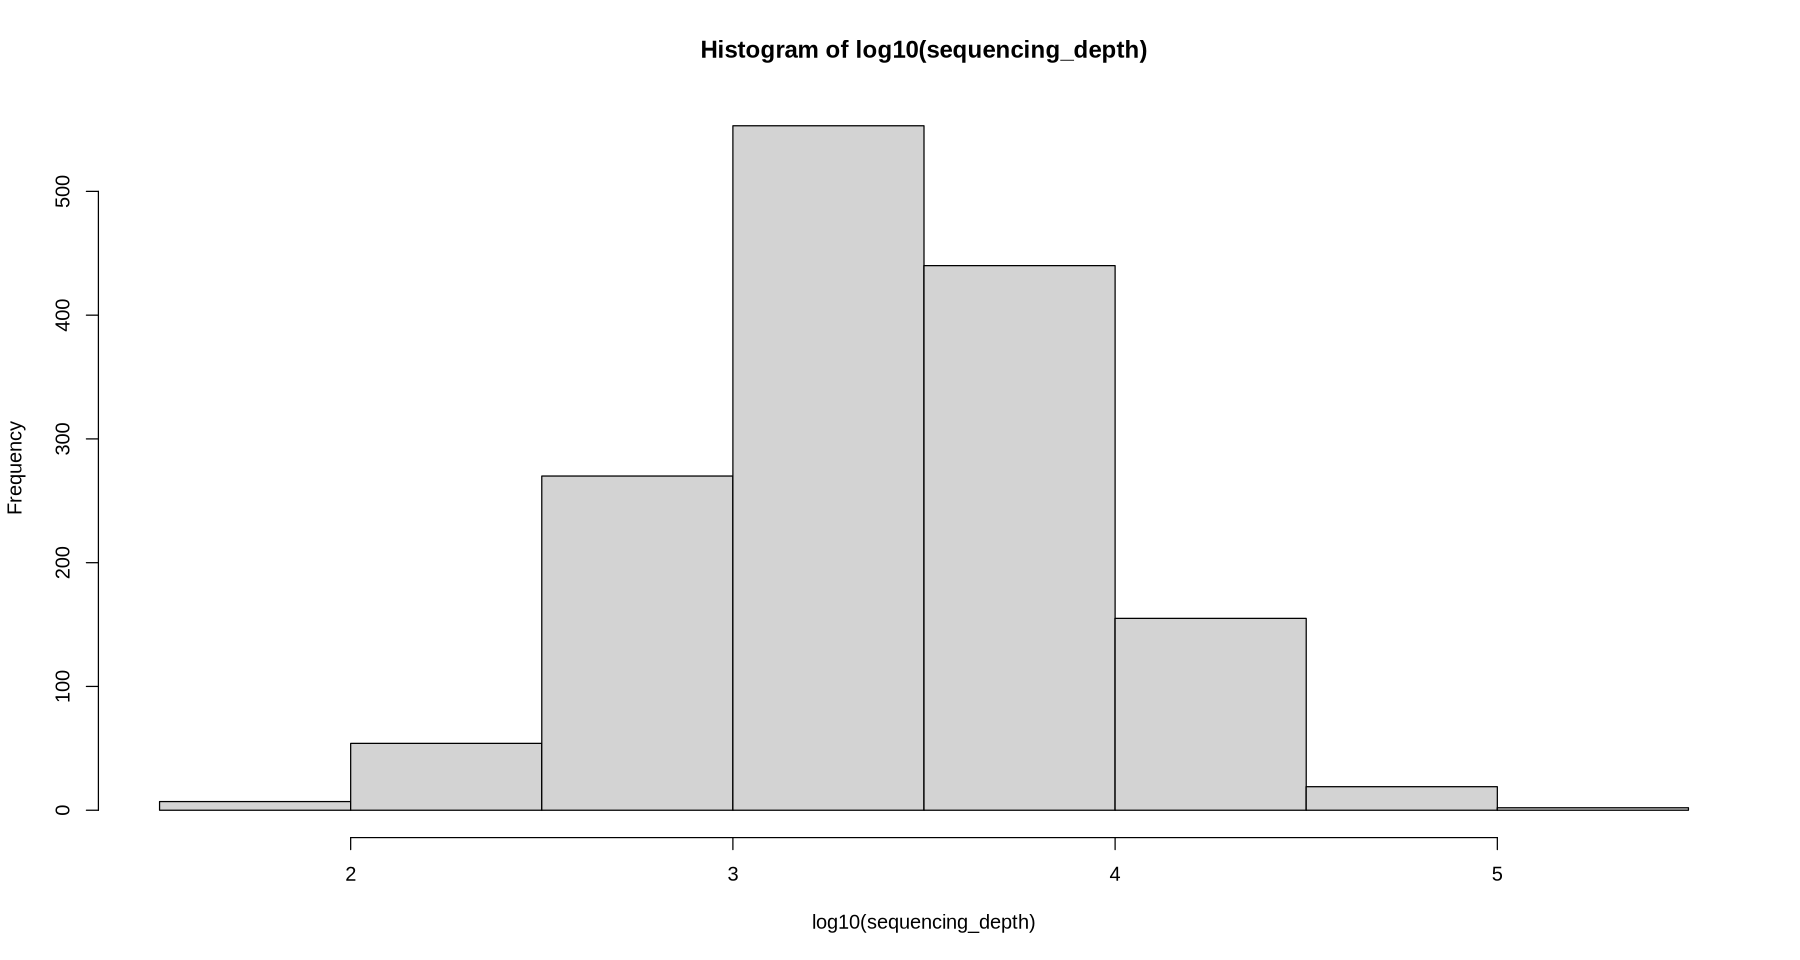

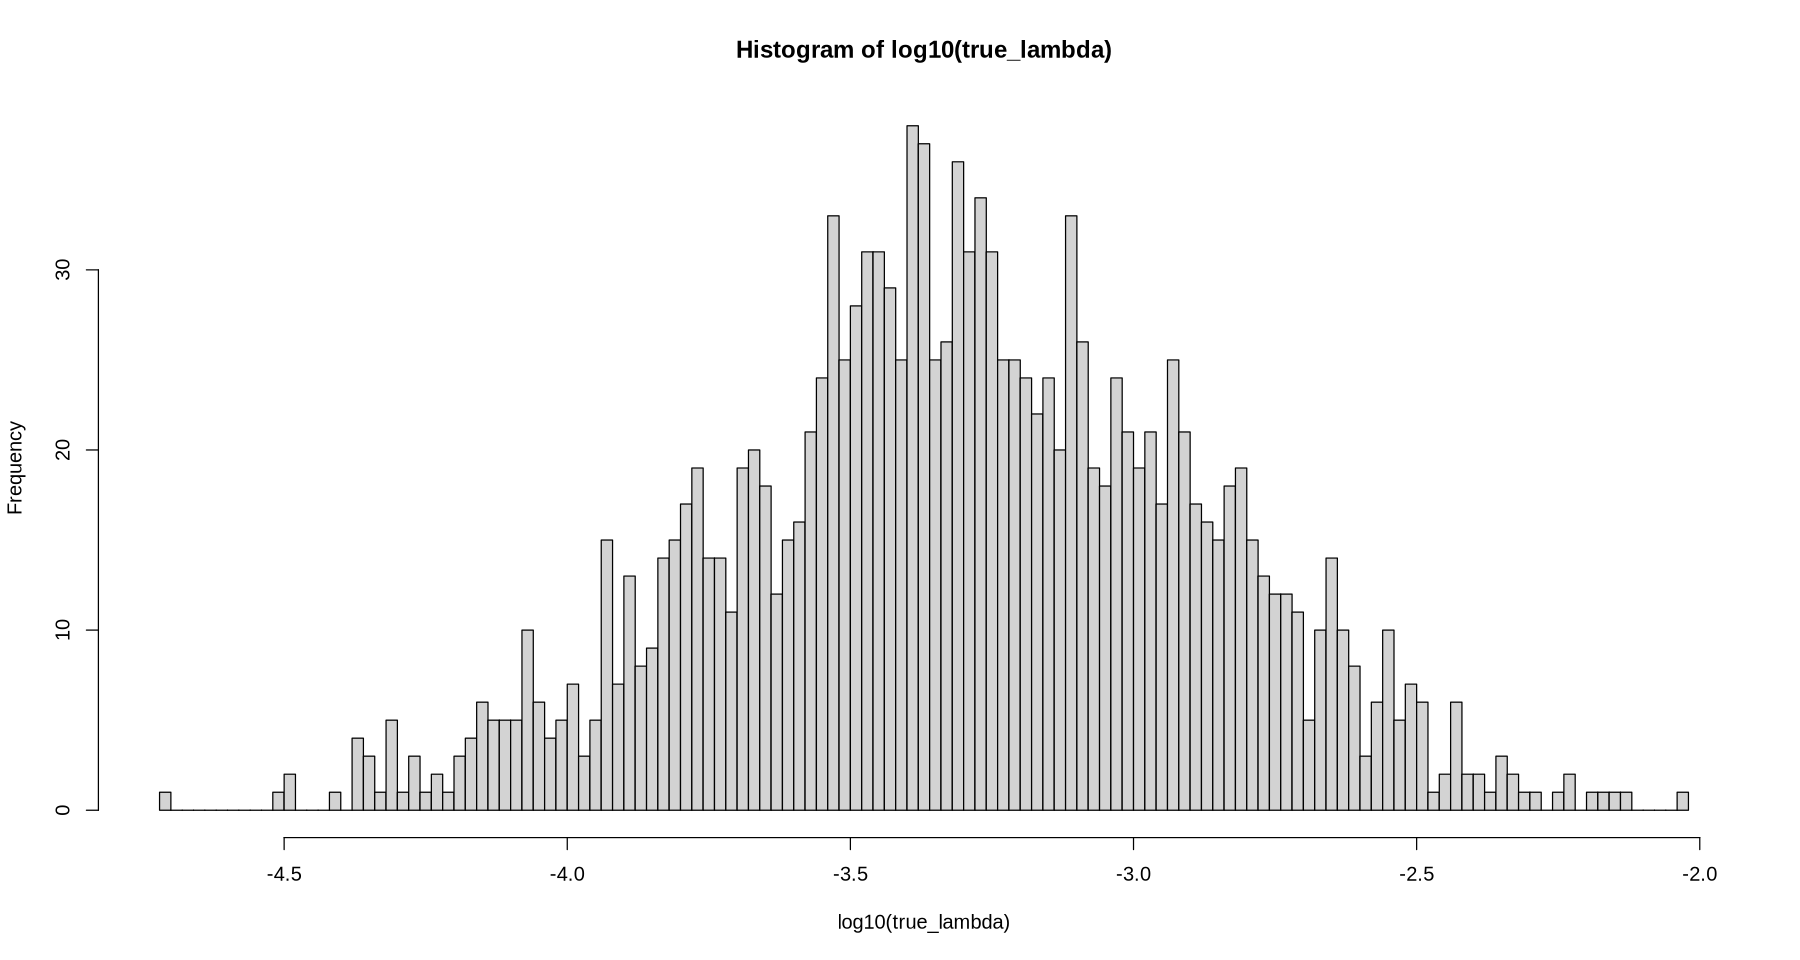

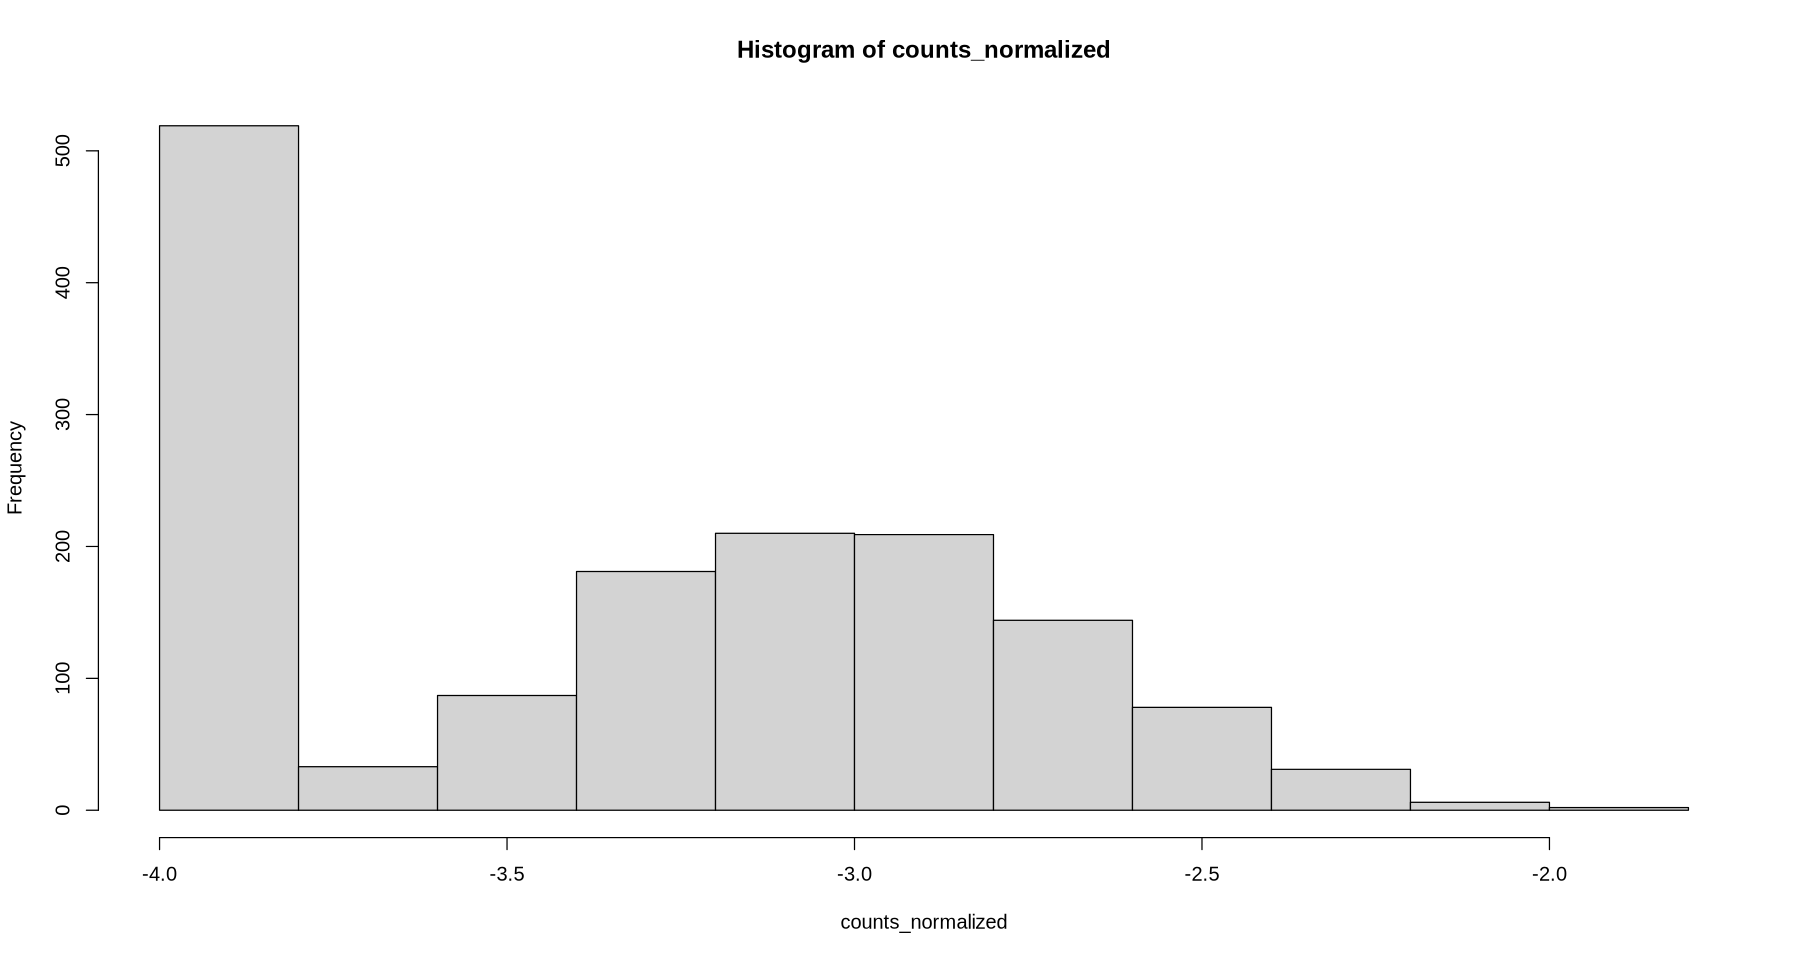

In [ ]:
# Number of cells to simulate
n <- 1500

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
true_lambda <- 10^rnorm(n, mean_rate, std_rate)
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rpois(n, true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)


### Negative binomial

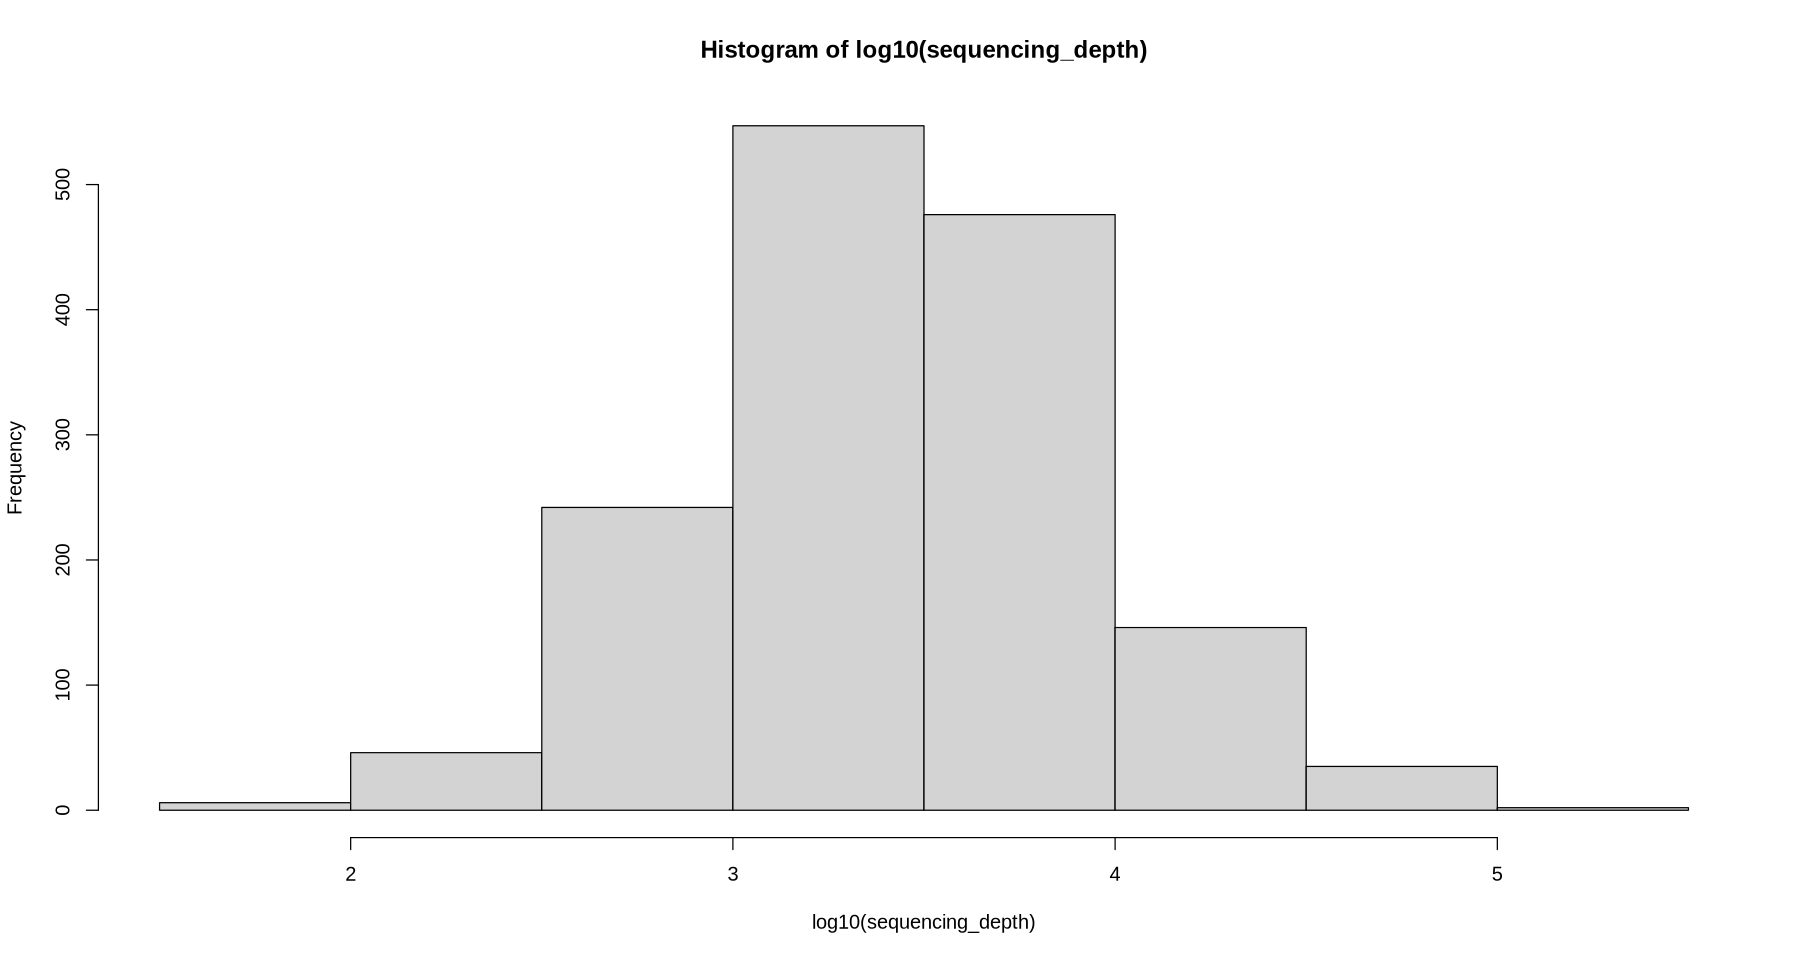

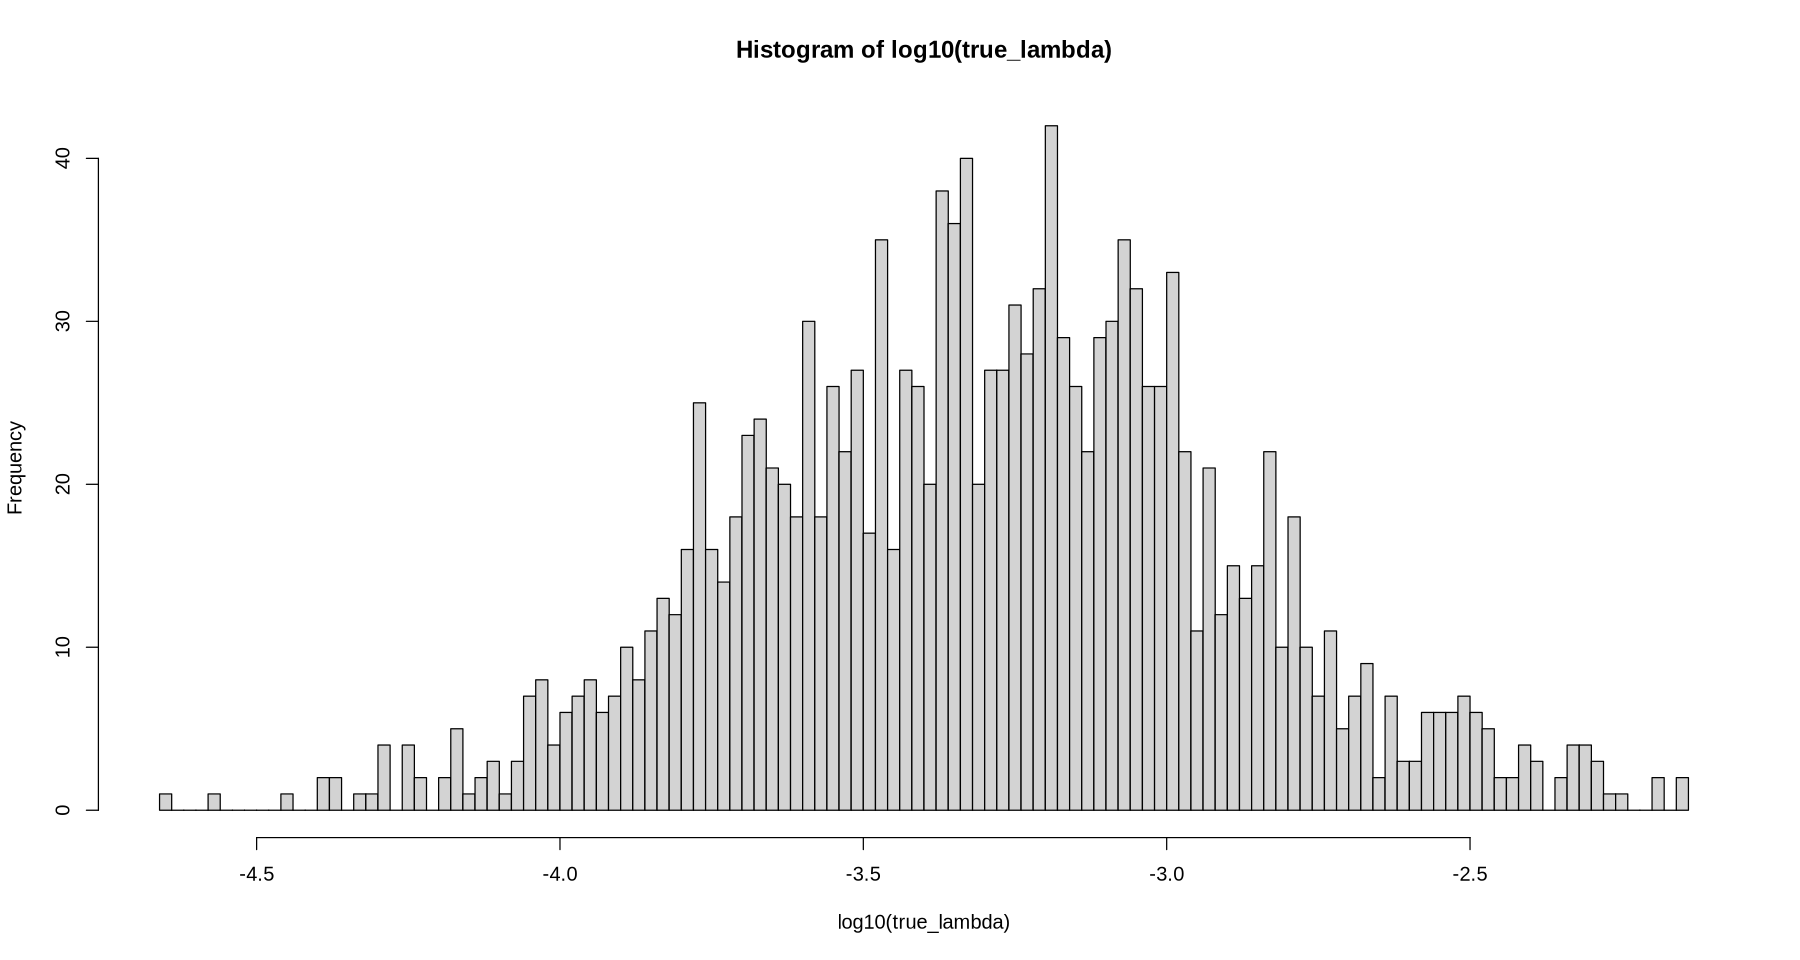

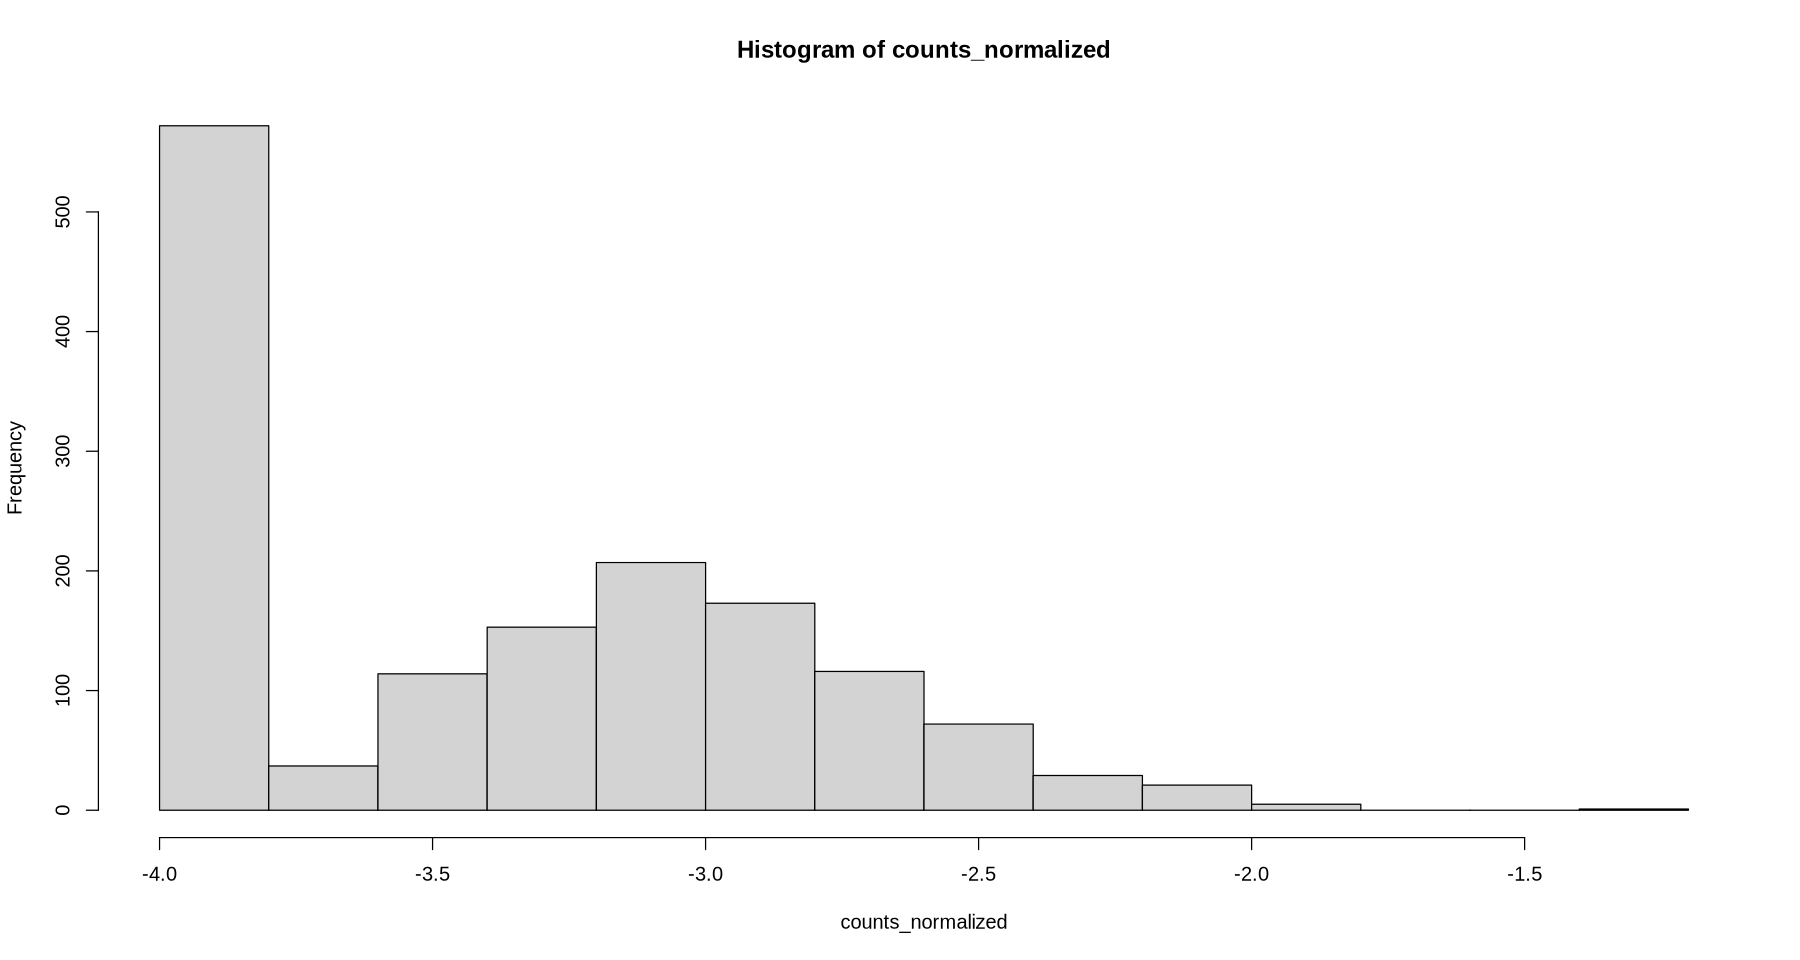

In [6]:
# Number of cells to simulate
n <- 1500

# Dispersion parameter
theta <- 3

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
true_lambda <- 10^rnorm(n, mean_rate, std_rate)
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rnbinom(n, size = theta, mu = true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)


## Bimodal data

### Poisson

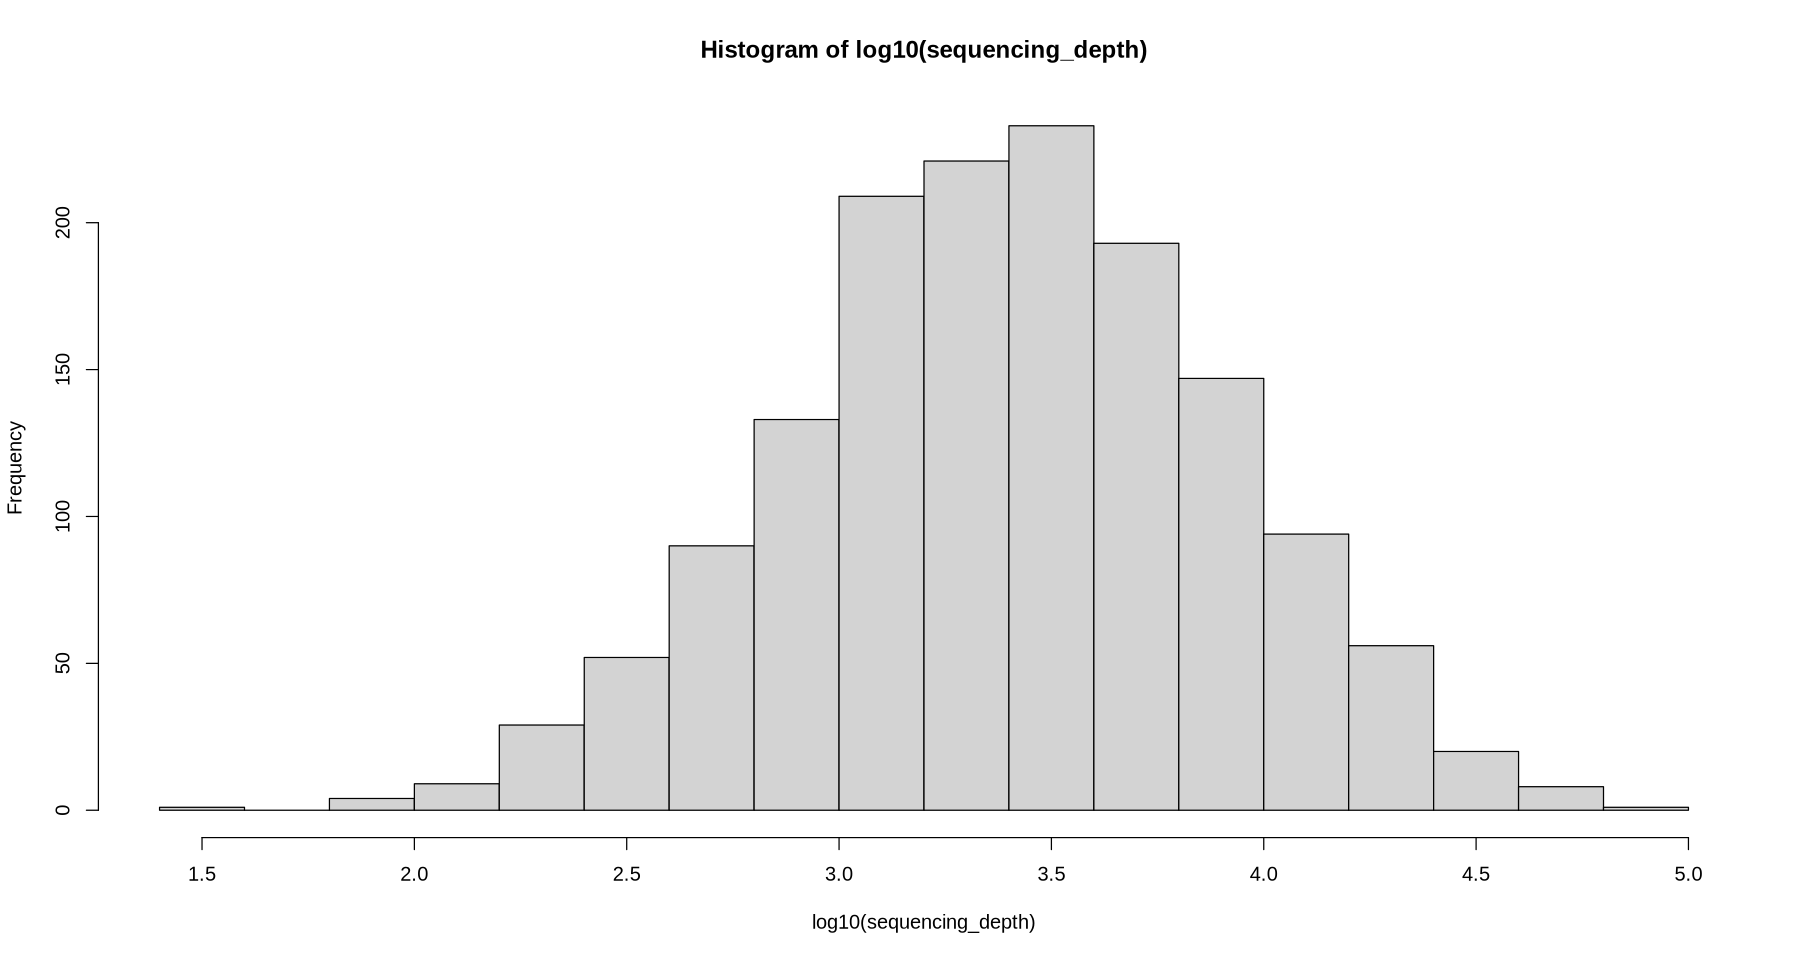

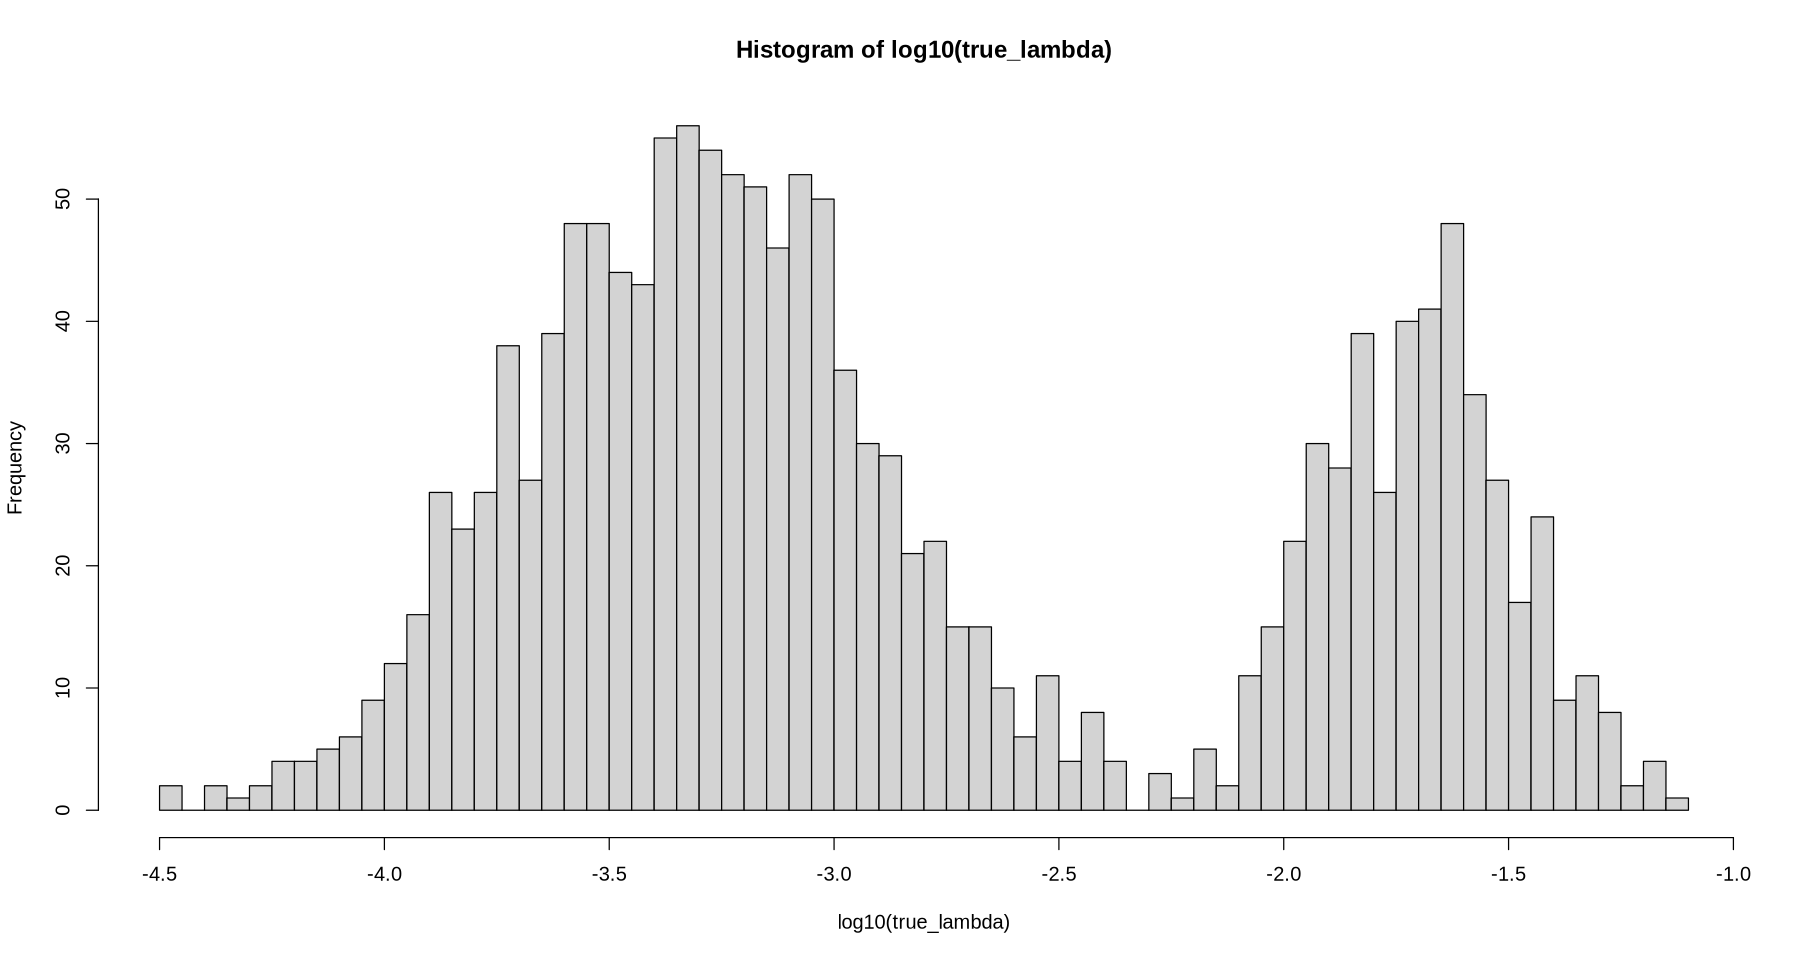

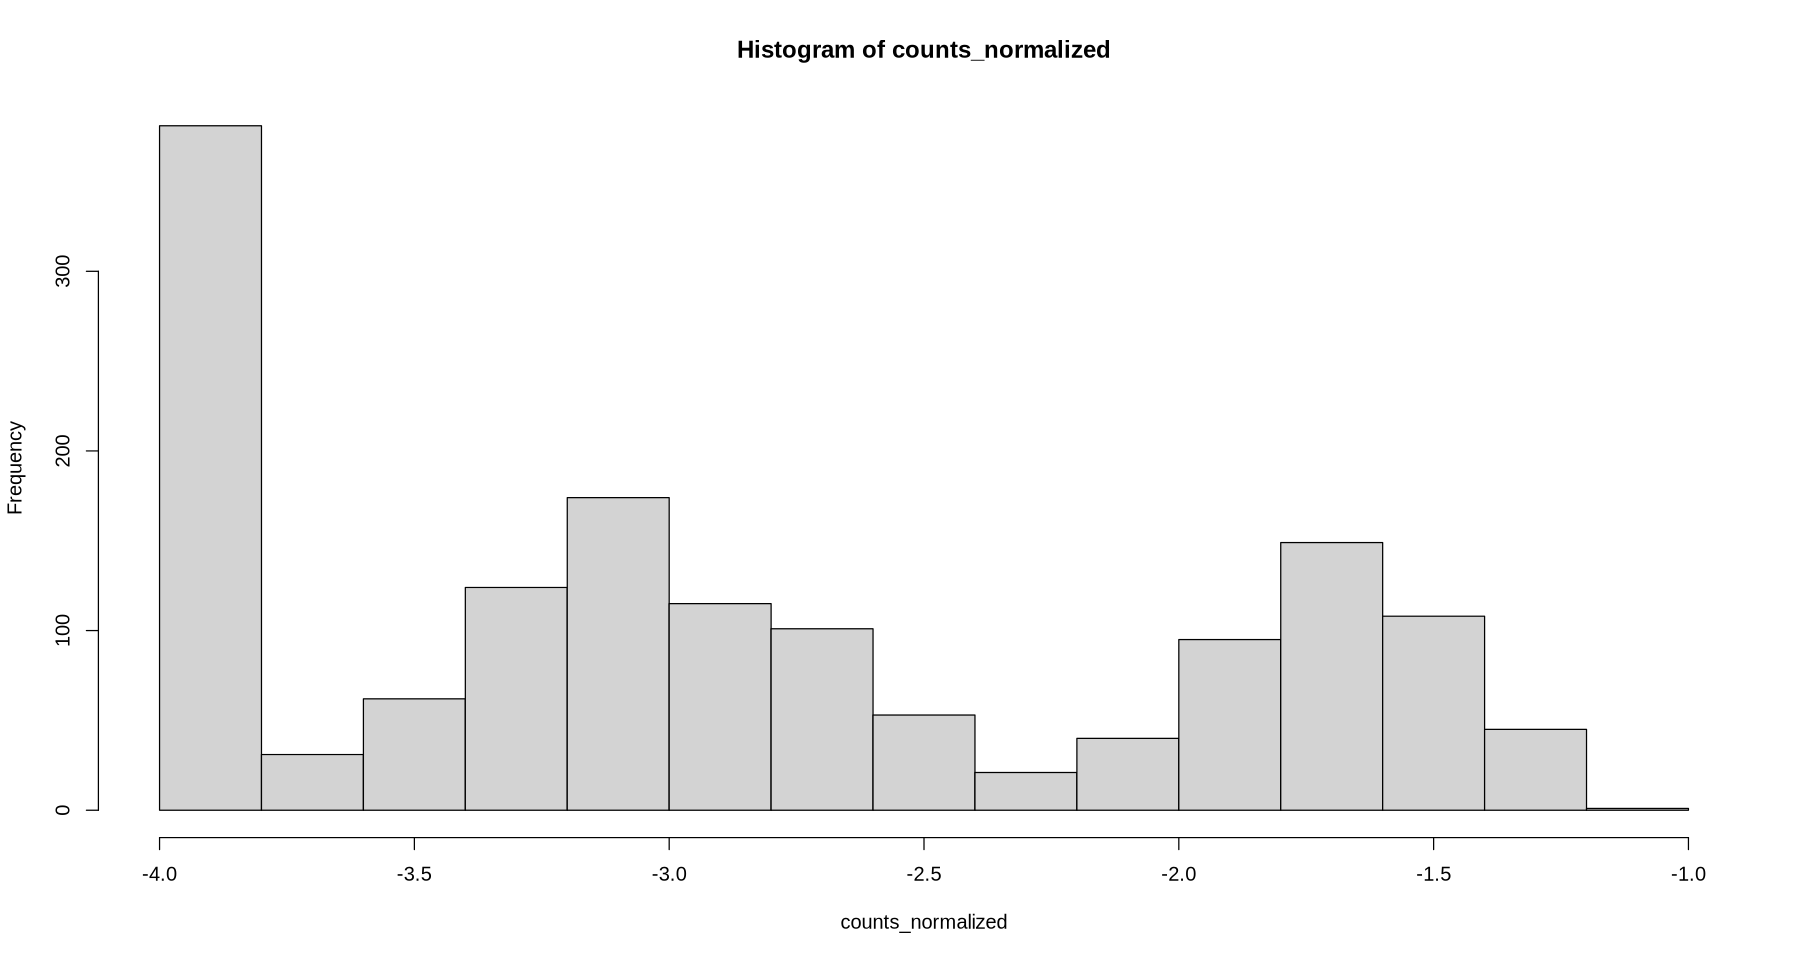

In [5]:
# Number of cells to simulate
n <- 1500

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
mean_rate_2 <- -1.7
std_rate_2 <- 0.2
true_lambda <- 10^ifelse(runif(n) < .7, rnorm(n, mean_rate, std_rate), rnorm(n, mean_rate_2, std_rate_2))
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rpois(n, true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)


### Negative binomial

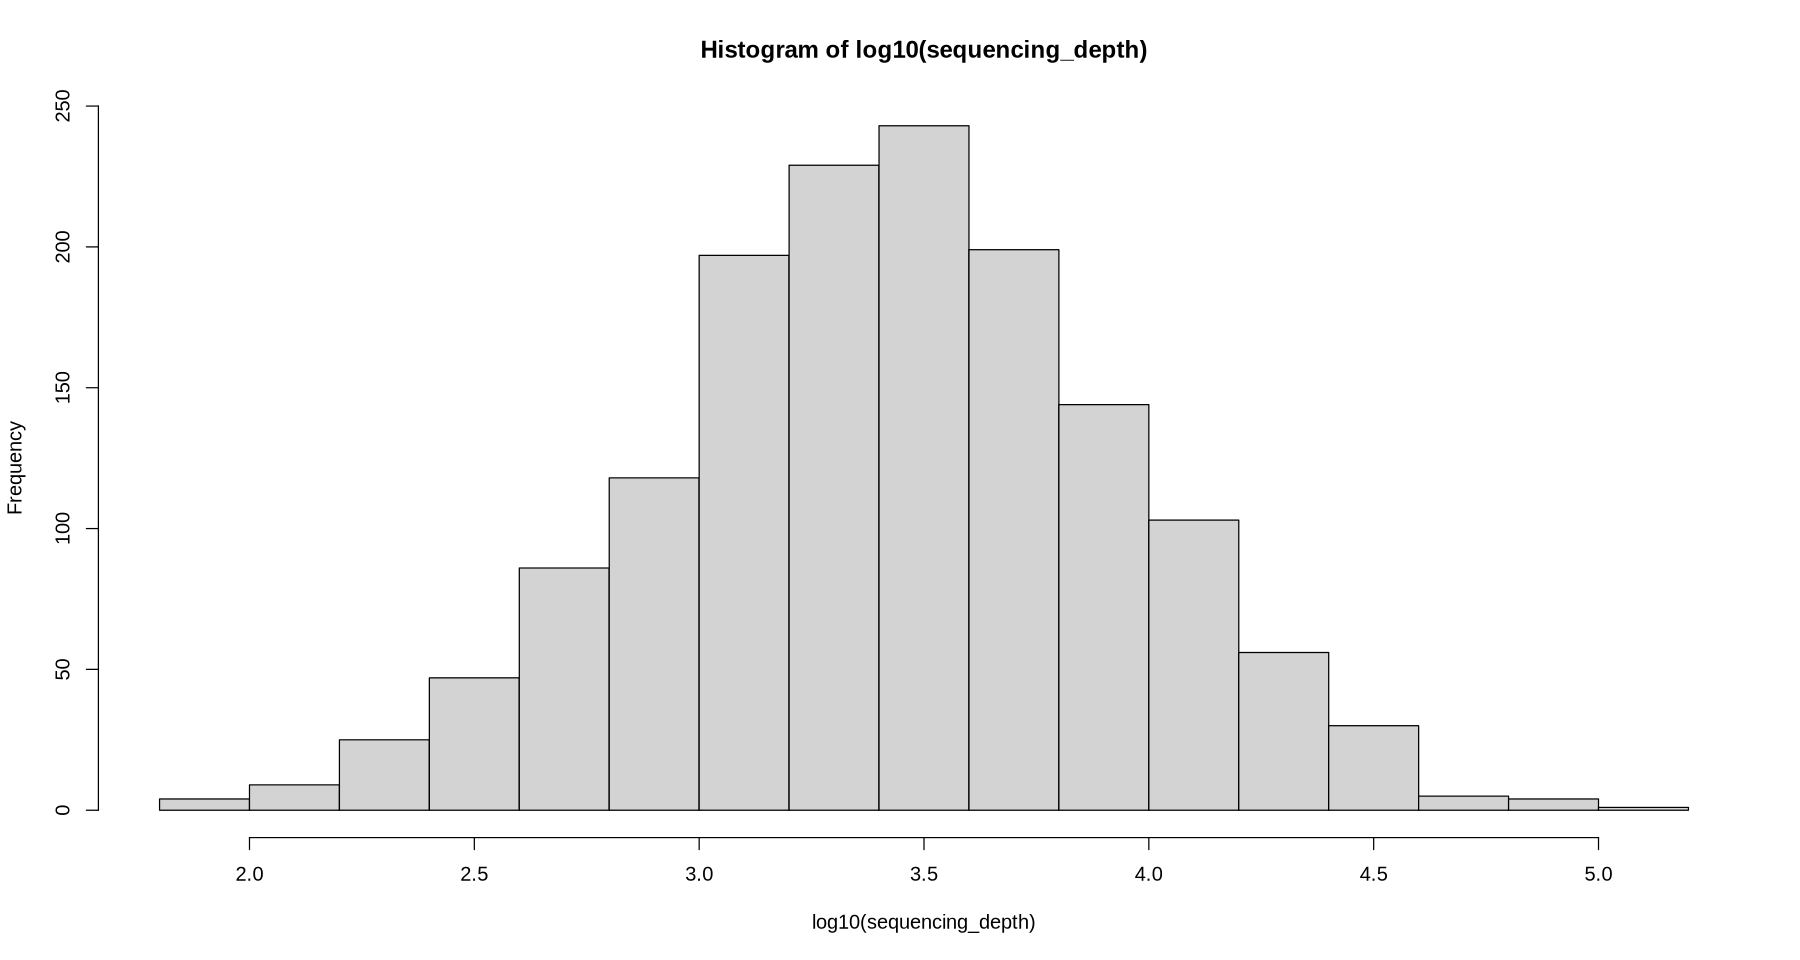

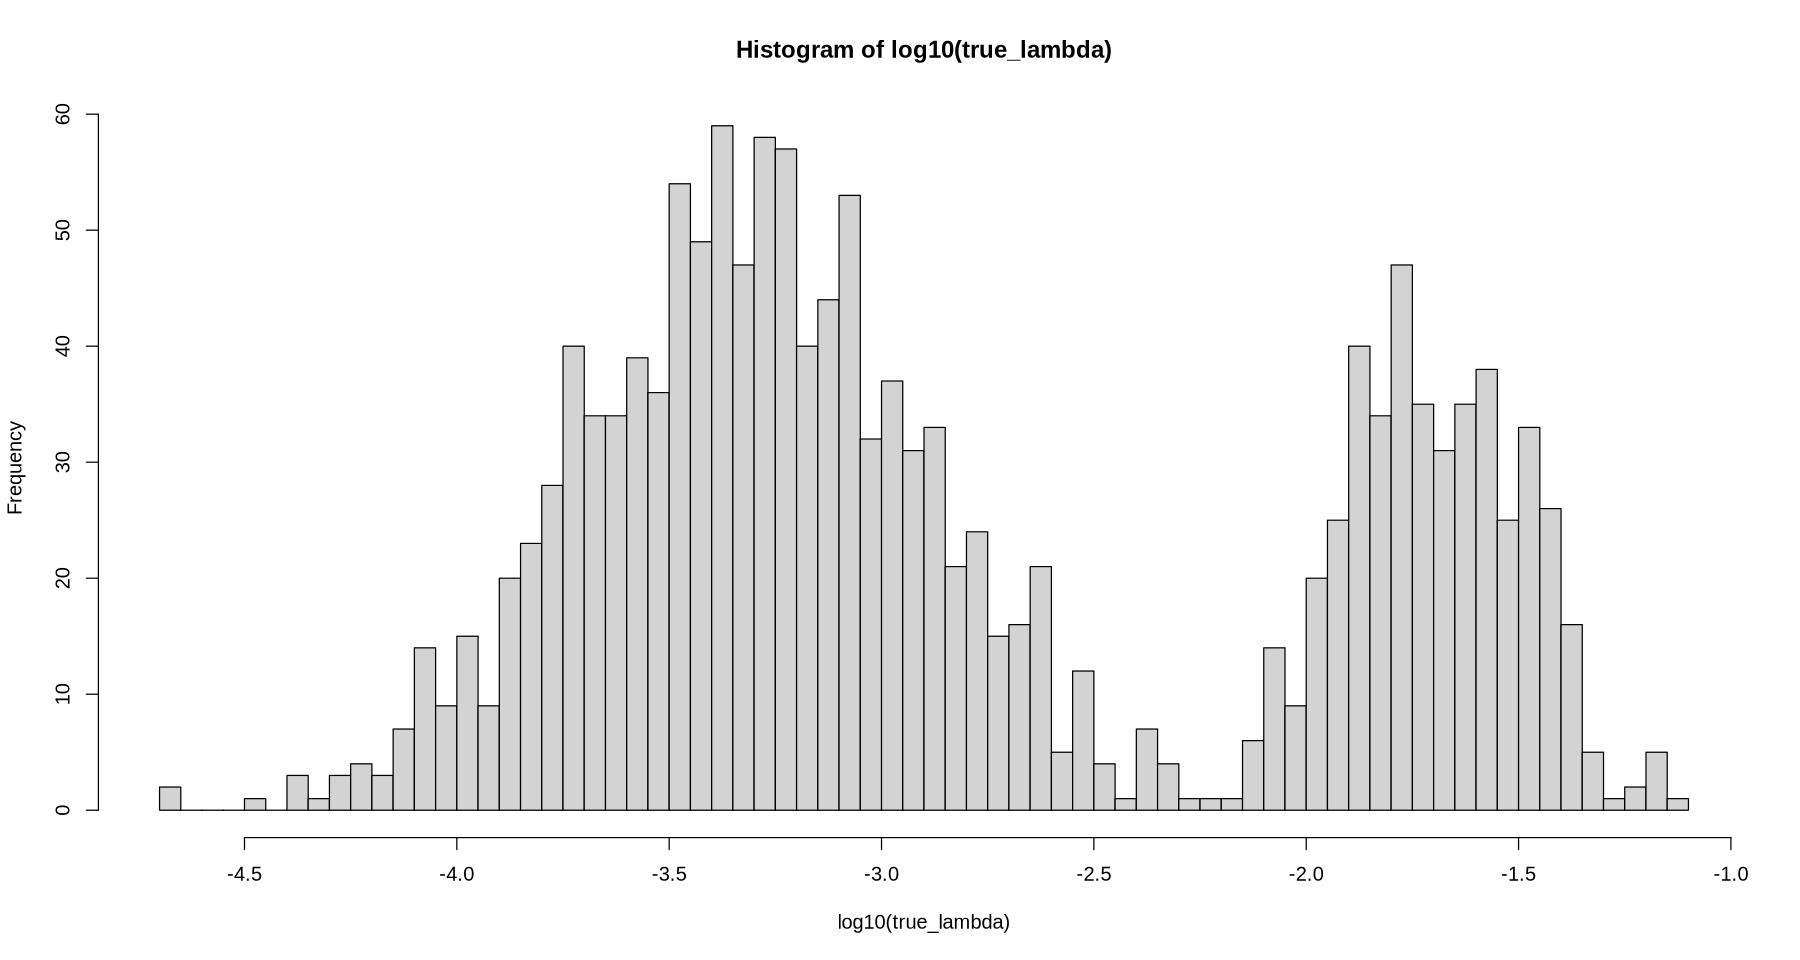

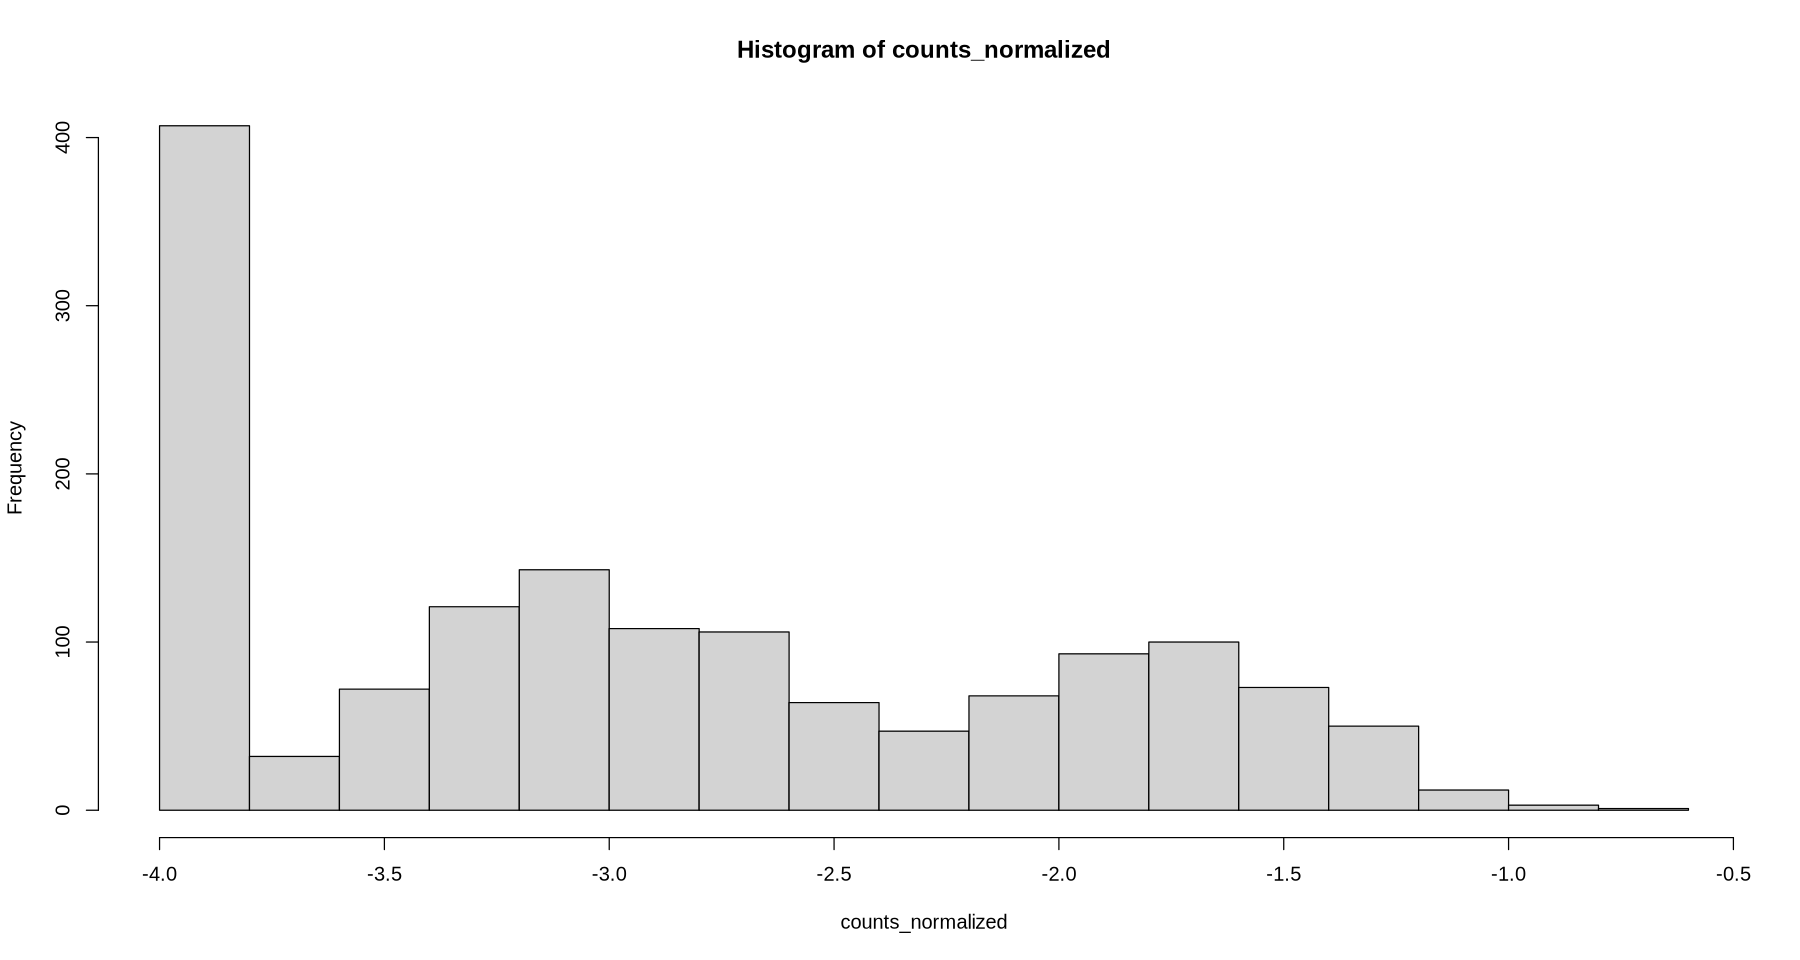

In [8]:
# Number of cells to simulate
n <- 1500

# Dispersion parameter
theta <- 3

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
mean_rate_2 <- -1.7
std_rate_2 <- 0.2
true_lambda <- 10^ifelse(runif(n) < .7, rnorm(n, mean_rate, std_rate), rnorm(n, mean_rate_2, std_rate_2))
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rnbinom(n, size = theta, mu = true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)


# Simulating multiple genes

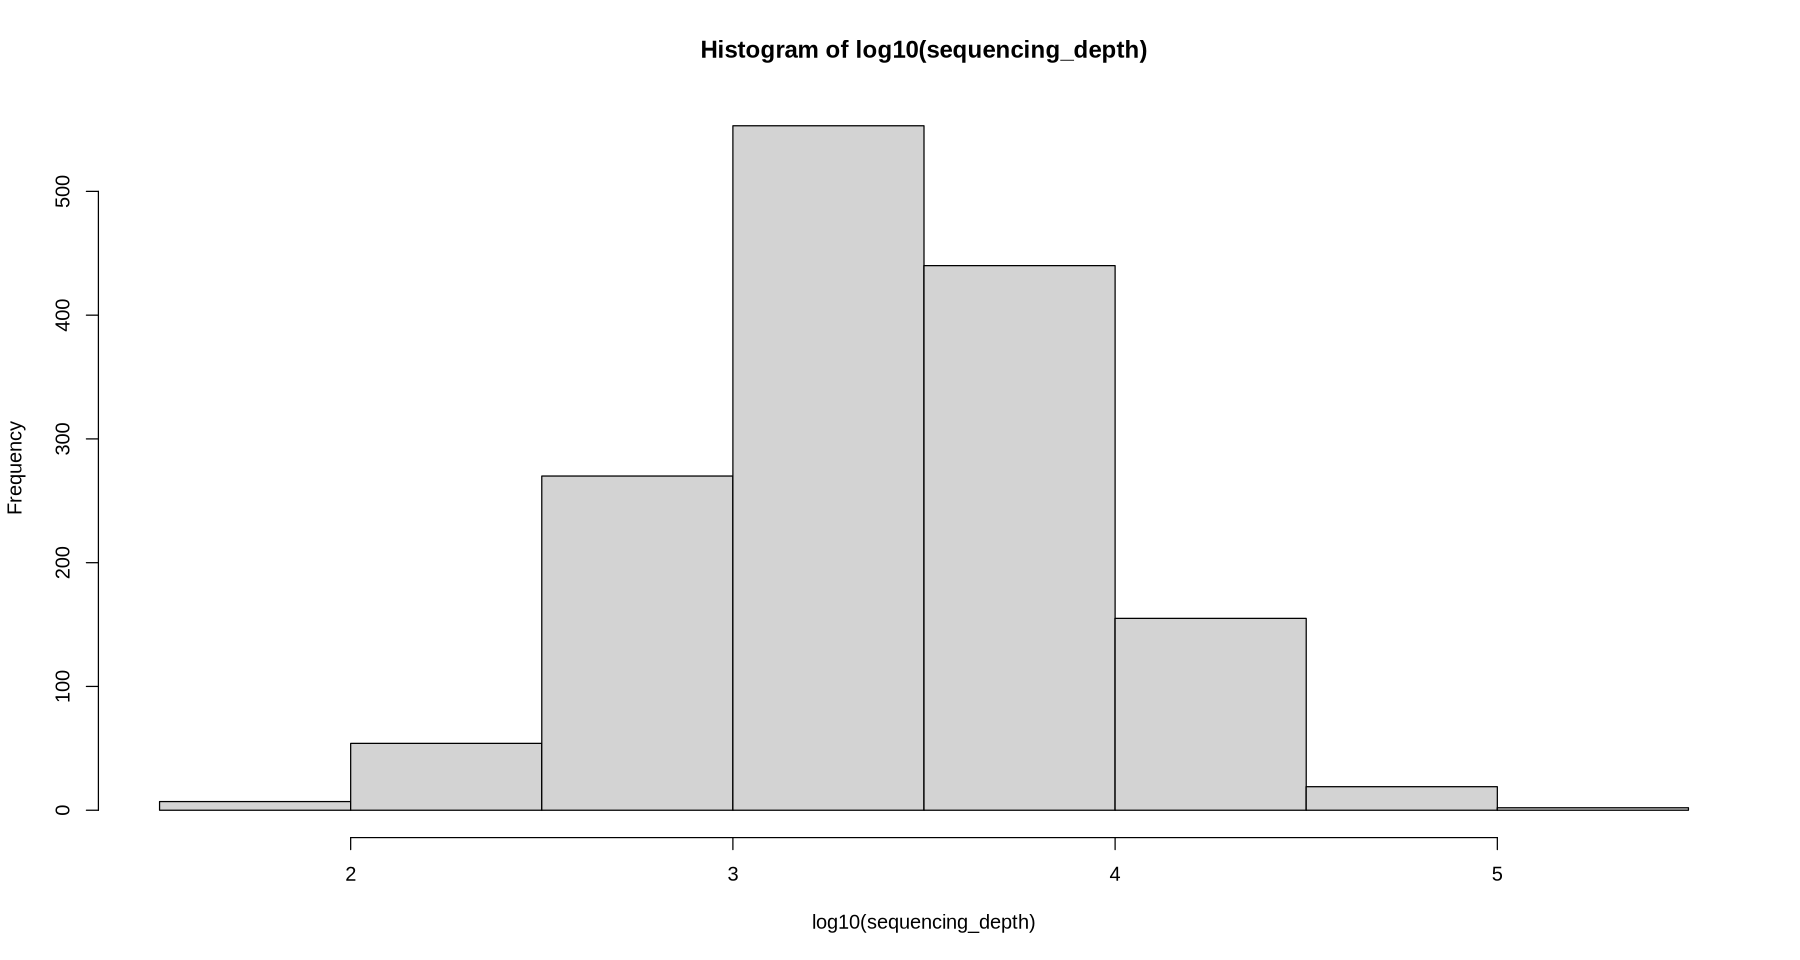

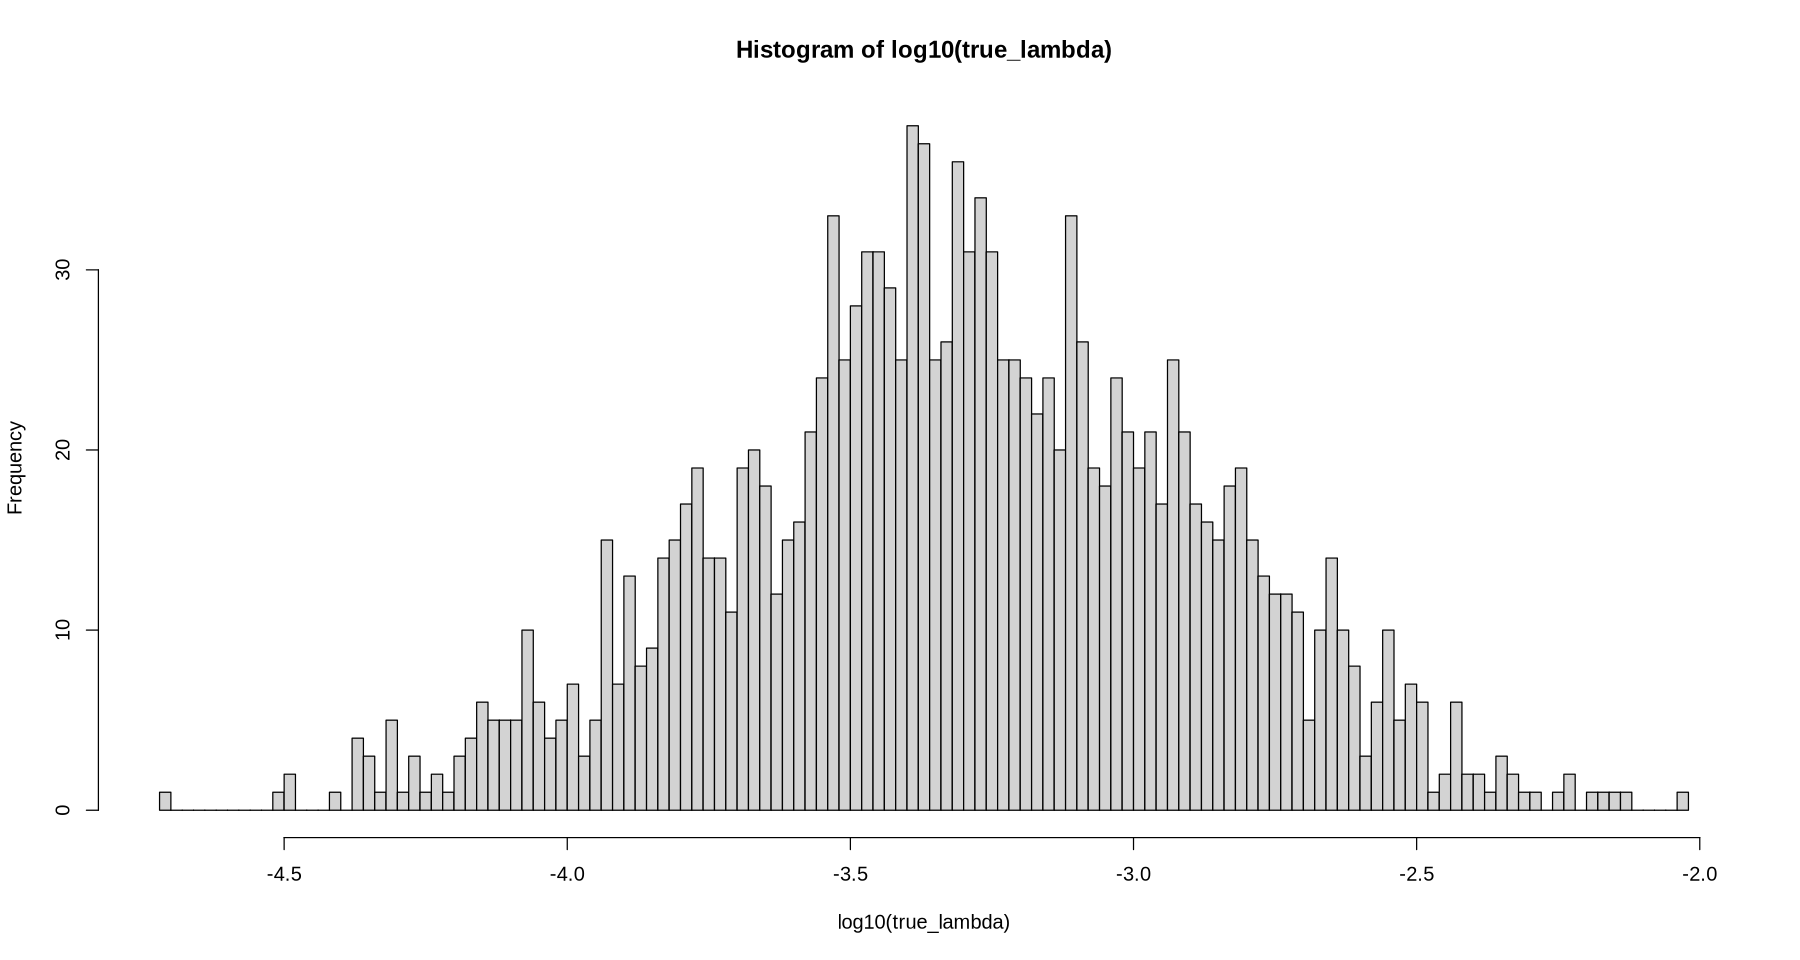

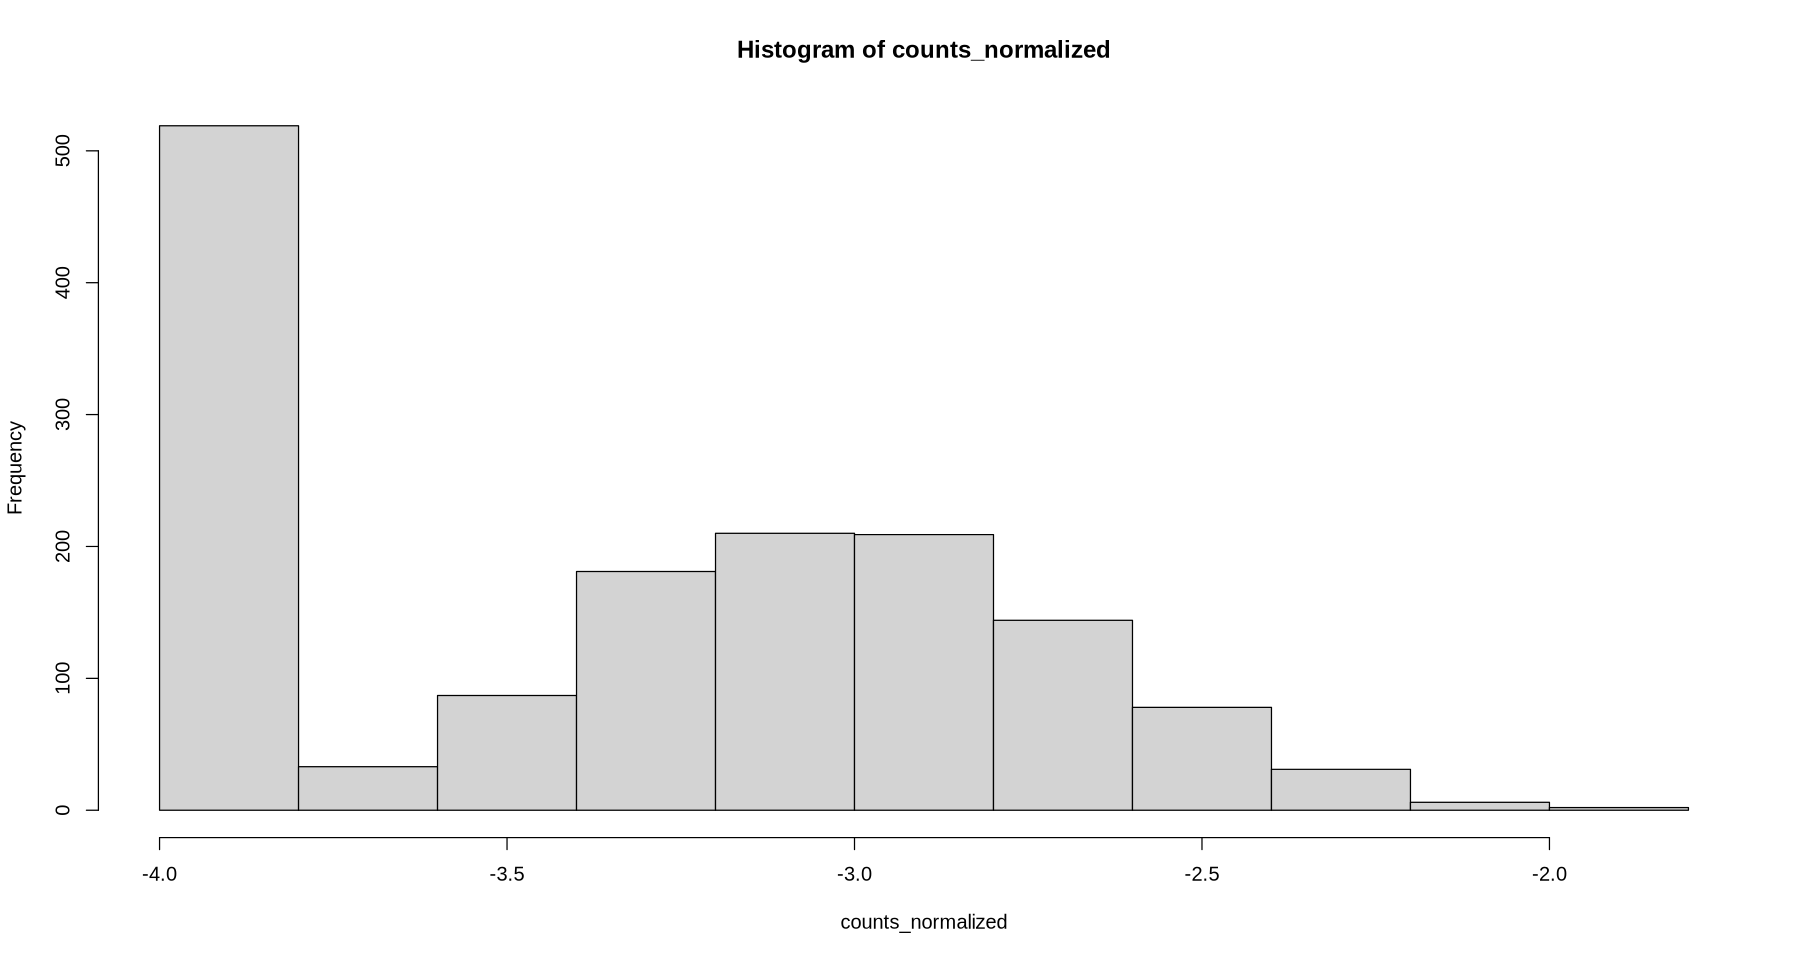

In [ ]:
# Number of genes to simulate
n_genes <- 1500

# Create gene-specific mean expressions and dispersions
gene_means <- 10^rnorm(num_genes, -3.3, .4)
gene_dispersion <- runif(num_genes, 1, 3) # Different dispersions per gene

# Number of cells to simulate
n_cells <- 1500

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n_cells, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
true_lambda <- 10^rnorm(n_cells, mean_rate, std_rate)
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rpois(n_cells, true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)
